# Copernicus Marine Service: Access Earth Observation Data
* Need to have an account on Copernicus Marine
* The ~/.netrc file contains the account credentials: your login and password for [Copernicus Marine](https://marine.copernicus.eu/)
```
$ more ~/.netrc
machine auth.marine.copernicus.eu
  login xxxxxxxxxx 
  password xxxxxxxxxxxxx
```

In [1]:
import copernicusmarine
import hvplot.xarray

In [2]:
# turn of some annoying warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
dataset_id = 'SST_MED_SST_L3S_NRT_OBSERVATIONS_010_012_b'

In [4]:
ds = copernicusmarine.open_dataset(dataset_id)

INFO - 2026-04-22T13:05:20Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  mazzabi1


Copernicus Marine password:

  ········


INFO - 2026-04-22T13:05:32Z - Selected dataset version: "202311"
INFO - 2026-04-22T13:05:32Z - Selected dataset part: "default"
WARNING - 2026-04-22T13:05:32Z - The dataset SST_MED_SST_L3S_NRT_OBSERVATIONS_010_012_b, version '202311', part 'default' is currently being updated. Data after 2026-04-22T00:00:00.000Z may not be up to date.


In [5]:
%%time
da = ds['adjusted_sea_surface_temperature'].sel(time='2025-10-01 16:00', method='nearest').load() - 273.15

CPU times: user 602 ms, sys: 418 ms, total: 1.02 s
Wall time: 1.24 s


In [6]:
da.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='turbo', tiles='OSM')

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (adjusted sea surface foundation temperature)

## Local CMEMS file: Mediterranean Physics (thetao & bottomT)

**Dataset**: `cmems_mod_med_phy-temp_my_4.2km_P1D-m` (Mediterranean Multiyear Physics, 4.2 km, daily).

Contains **90 days (Jan–Mar 2026)** of:
- `thetao` — potential temperature at 1 m depth
- `bottomT` — bottom temperature

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import hvplot.xarray  # noqa: F401

local_nc = 'cmems_mod_med_phy-temp_my_4.2km_P1D-m_1776862674750.nc'
ds_med = xr.open_dataset(local_nc)
ds_med

<xarray.Dataset> Size: 238kB
Dimensions:    (time: 90, latitude: 15, longitude: 22, depth: 1)
Coordinates:
  * time       (time) datetime64[ns] 720B 2026-01-01 2026-01-02 ... 2026-03-31
  * latitude   (latitude) float32 60B 36.6 36.65 36.69 ... 37.1 37.15 37.19
  * longitude  (longitude) float32 88B 10.0 10.04 10.08 ... 10.79 10.83 10.88
  * depth      (depth) float32 4B 1.018
Data variables:
    bottomT    (time, latitude, longitude) float32 119kB ...
    thetao     (time, depth, latitude, longitude) float32 119kB ...
Attributes:
    Conventions:       CF-1.11
    title:             Potential Temperature (3D) - Daily Mean
    institution:       Centro Euro-Mediterraneo sui Cambiamenti Climatici - C...
    source:            MFS E3R1I
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        Escudier, R., Clementi, E., Omar, M., Cipollone, A., P...
    comment:           Please check in CMEMS catalogue the INFO section for p...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  MEDSEA_MULTIYEAR_PHY_006_004
    subset:datasetId:  cmems_mod_med_phy-temp_my_4.2km_P1D-m_202511
    subset:date:       2026-04-22T12:57:54.751Z

In [8]:
# Inspect available variables, dimensions, and time range
print('Variables :', list(ds_med.data_vars))
print('Dimensions:', dict(ds_med.sizes))
print('Time range:', str(ds_med.time.values[0])[:10], '->', str(ds_med.time.values[-1])[:10])

Variables : ['bottomT', 'thetao']
Dimensions: {'time': 90, 'latitude': 15, 'longitude': 22, 'depth': 1}
Time range: 2026-01-01 -> 2026-03-31


### 1. Spatial map — surface temperature (`thetao` at 1 m) on the first day

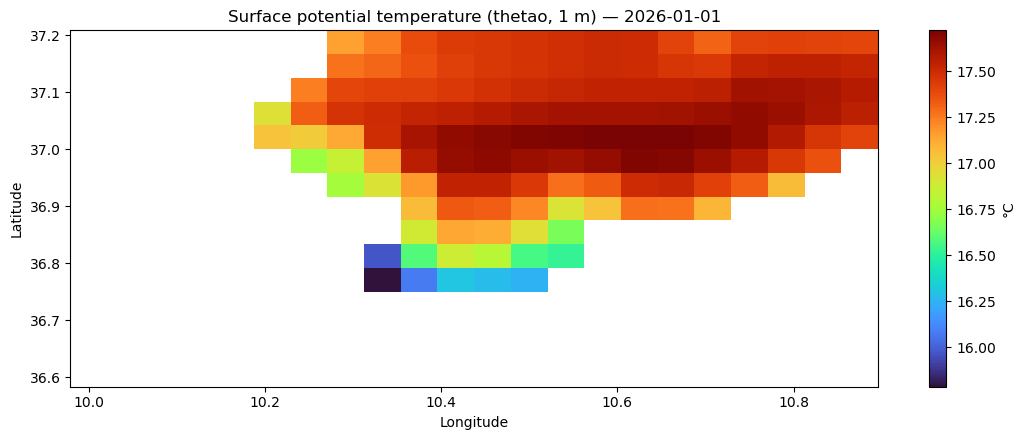

In [9]:
# Select first time step; squeeze depth if present
sst0 = ds_med['thetao'].isel(time=0)
if 'depth' in sst0.dims:
    sst0 = sst0.isel(depth=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
im = sst0.plot(ax=ax, cmap='turbo', cbar_kwargs={'label': '°C'})
ax.set_title(f"Surface potential temperature (thetao, 1 m) — {str(sst0.time.values)[:10]}")
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

### 2. Spatial map — bottom temperature (`bottomT`) on the first day

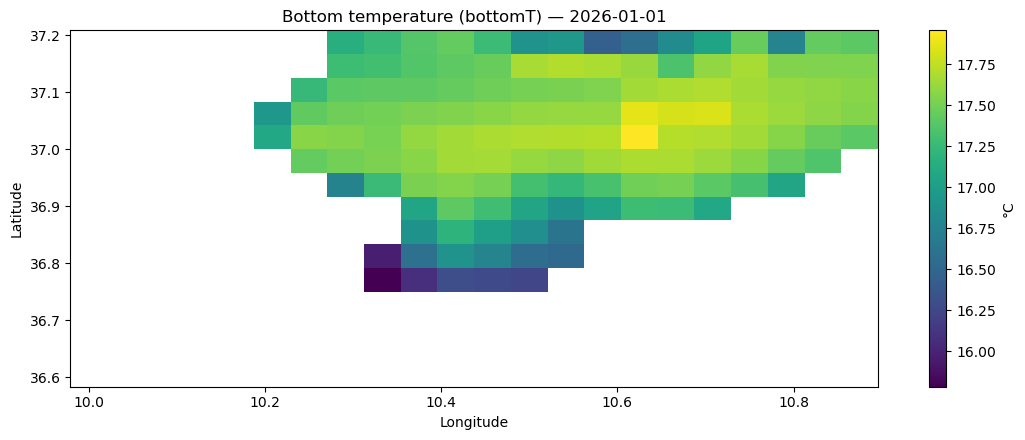

In [10]:
bt0 = ds_med['bottomT'].isel(time=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
bt0.plot(ax=ax, cmap='viridis', cbar_kwargs={'label': '°C'})
ax.set_title(f"Bottom temperature (bottomT) — {str(bt0.time.values)[:10]}")
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

### 3. Basin-averaged daily time series (Jan–Mar 2026)

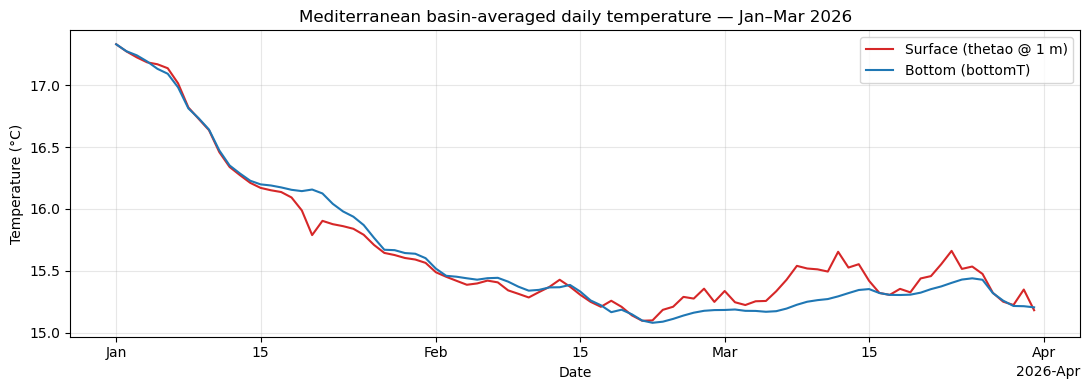

In [11]:
thetao = ds_med['thetao']
if 'depth' in thetao.dims:
    thetao = thetao.isel(depth=0)

ts_surf = thetao.mean(dim=[d for d in thetao.dims if d != 'time'])
ts_bot  = ds_med['bottomT'].mean(dim=[d for d in ds_med['bottomT'].dims if d != 'time'])

fig, ax = plt.subplots(figsize=(11, 4))
ts_surf.plot(ax=ax, label='Surface (thetao @ 1 m)', color='tab:red')
ts_bot.plot(ax=ax, label='Bottom (bottomT)', color='tab:blue')
ax.set_ylabel('Temperature (°C)'); ax.set_xlabel('Date')
ax.set_title('Mediterranean basin-averaged daily temperature — Jan–Mar 2026')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 4. Temporal mean maps over the 90-day period

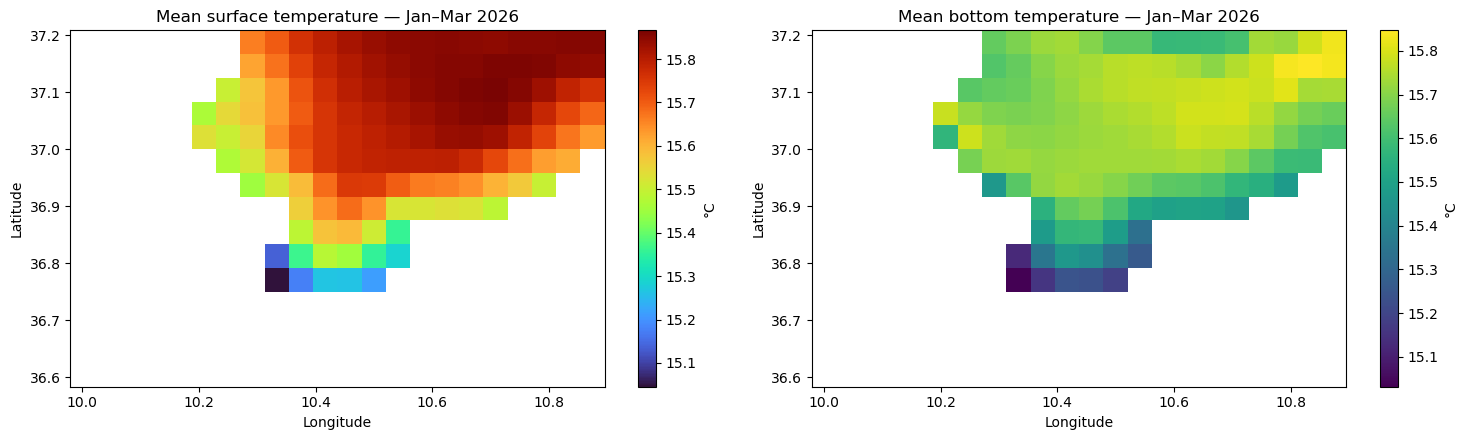

In [12]:
mean_surf = thetao.mean(dim='time')
mean_bot  = ds_med['bottomT'].mean(dim='time')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
mean_surf.plot(ax=axes[0], cmap='turbo', cbar_kwargs={'label': '°C'})
axes[0].set_title('Mean surface temperature — Jan–Mar 2026')
mean_bot.plot(ax=axes[1], cmap='viridis', cbar_kwargs={'label': '°C'})
axes[1].set_title('Mean bottom temperature — Jan–Mar 2026')
for ax in axes:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

### 5. Interactive map with hvplot (surface temperature, time slider)

In [13]:
thetao.hvplot(
    x='longitude', y='latitude', groupby='time',
    rasterize=True, cmap='turbo', geo=True, tiles='OSM',
    clabel='°C', title='thetao (1 m) — daily'
)

:DynamicMap   [time]
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (Potential temperature)